In [ ]:
#Baixar DATASET

import kagglehub

# Download latest version
path = kagglehub.dataset_download("oliveirasp6/poems-in-portuguese")

print("Path to dataset files:", path)

# Tarefa 1: Preparação e Análise Exploratória

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Carregar o dataset
df = pd.read_csv('..\dataset\portuguese-poems.csv', encoding='utf-8')

In [6]:
# 2. Explorar estrutura
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(df.head(10))

Shape: (15543, 4)
Colunas: ['Author', 'Title', 'Content', 'Views']
                       Author                                  Title  \
0            Cecília Meireles                                Retrato   
1             Fernando Pessoa      Para ser grande, sê inteiro: nada   
2            Marina Colasanti                  Eu sei, mas não devia   
3  Carlos Drummond de Andrade                              Quadrilha   
4          Eugénio de Andrade                       É urgente o amor   
5          Vinicius de Moraes                    Procura-se um amigo   
6             Fernando Pessoa                       X. MAR PORTUGUÊS   
7          Vinicius de Moraes                     Eu sei e você sabe   
8              Gonçalves Dias                         Como eu te amo   
9             Manuel Bandeira  Poema tirado de uma notícia de jornal   

                                             Content    Views  
0  Eu não tinha este rosto de hoje,\r\nAssim calm...  1018431  
1  Para ser 

In [85]:
# 2.1 Limpeza e validação do dataset
print(df.isna().sum())
df = df.dropna(axis='index')

print("Poemas Duplicados: ", df.duplicated().sum())

Author     0
Title      0
Content    0
Views      0
dtype: int64
Poemas Duplicados:  0


O Dataset é formado por 4 colunas, e 15.543 registros. <br>
As colunas são dividas em Autor, Titulo, Conteudo, e Visualizações.



In [8]:
# 3. Listar todos os autores
autores_unicos = df['Author'].unique()
print(f"Total de autores: {len(autores_unicos)}")
print(autores_unicos[:20])

Total de autores: 2127
['Cecília Meireles' 'Fernando Pessoa' 'Marina Colasanti'
 'Carlos Drummond de Andrade' 'Eugénio de Andrade' 'Vinicius de Moraes'
 'Gonçalves Dias' 'Manuel Bandeira' 'Sophia de Mello Breyner Andresen'
 'Chacal' 'Miguel Torga' 'Clarice Lispector' 'Thiago de Mello'
 'Bertolt Brecht' 'Florbela Espanca' 'João Roiz de Castelo-Branco'
 'Mário de Sá-Carneiro' "Alexandre O'Neill" 'José Gomes Ferreira'
 'Sebastião da Gama']


O dataset é formado por um número total de 2.127 autores.

In [9]:
# 4. Contar poemas por autor
autor_counts = df['Author'].value_counts()
print(autor_counts.head(15))

Author
Fernando Pessoa                     2232
Sophia de Mello Breyner Andresen     442
Jorge Luis Borges                    417
Florbela Espanca                     347
Angela Santos                        257
Nuno Júdice                          231
Castro Alves                         222
Ruy Belo                             193
Reinaldo Ferreira                    101
Manuel António Pina                   98
Paulo Leminski                        97
Carlos Drummond de Andrade            91
Bocage                                88
Álvares de Azevedo                    86
Manuel Bandeira                       83
Name: count, dtype: int64


O autor com mais poemas no dataset é Fernando Pessoa, com 2.232 poemas.

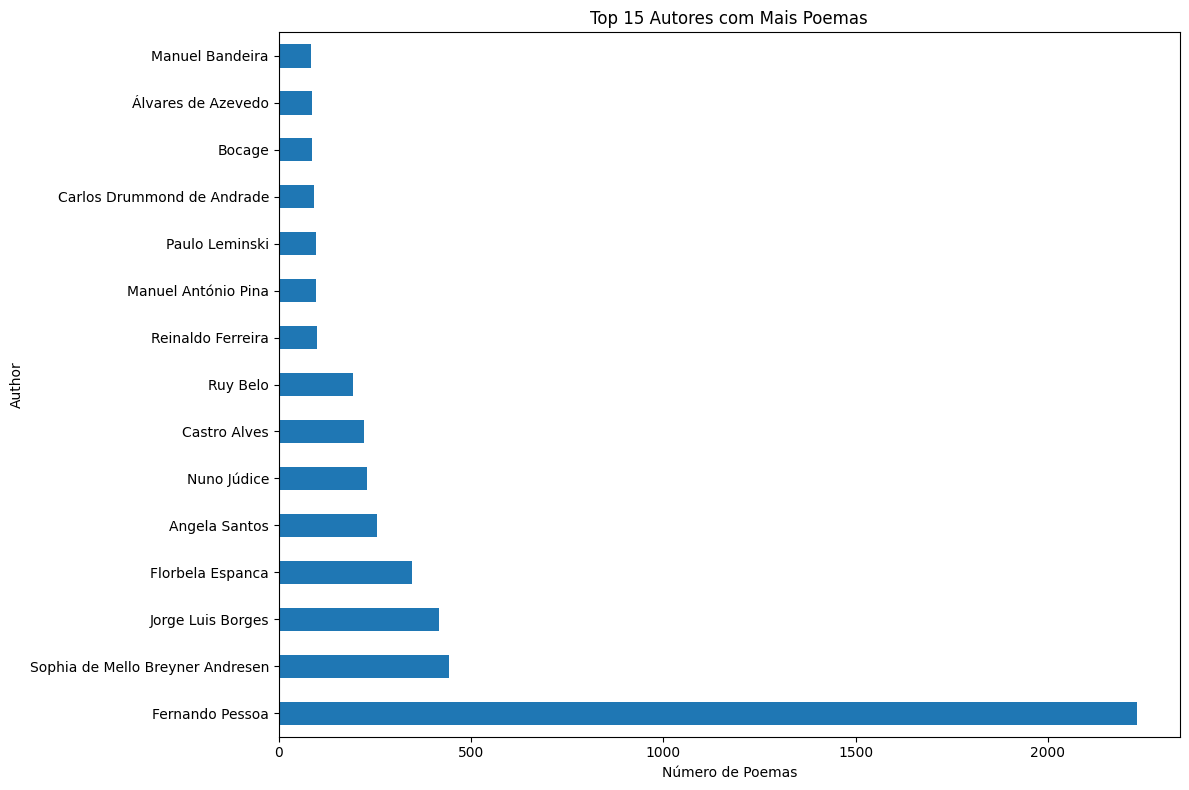

In [10]:
# 5. Visualizar distribuição
plt.figure(figsize=(12, 8))
autor_counts.head(15).plot(kind='barh')
plt.xlabel('Número de Poemas')
plt.title('Top 15 Autores com Mais Poemas')
plt.tight_layout()
plt.savefig('autores_distribution.png', dpi=150)
plt.show()

In [31]:
# 6. Filtrar heterônimos de Fernando Pessoa
heteronimos = ['Fernando Pessoa', 'Alberto Caeiro', 'Álvaro de Campos', 'Ricardo Reis']
df_pessoa = df[df['Author'].isin(heteronimos)].copy()
print(f"\nPoemas de Fernando Pessoa e heterônimos: {len(df_pessoa)}")
print(df_pessoa['Author'].value_counts())


Poemas de Fernando Pessoa e heterônimos: 2232
Author
Fernando Pessoa    2232
Name: count, dtype: int64


# Tarefa 2: Pré-processamento de Texto em Português

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Baixar recursos do NLTK
nltk.download('stopwords') #frequently occurring, low-information words
nltk.download('punkt') #dividir textos em sentenças ou palavras
nltk.download('punkt_tab') #divides a text into a list of sentences

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [16]:
# Carregar stopwords português
stop_words = set(stopwords.words('portuguese'))

In [32]:
# 1. Limpeza de pontuação
df_pessoa['texto_limpo'] = df_pessoa['Content'].str.lower()

df_pessoa['texto_limpo'] = df_pessoa['texto_limpo'].str.replace(
    r'[,.:;!?\'"-()\\[\\]{}]', ' ', regex=True)

df_pessoa['texto_limpo'] = df_pessoa['texto_limpo'].str.replace(
    r'\\s+', ' ', regex=True)

1. Limpando o texto, reduzimos para caixa baixa.
2. Removemos pontuação ou caracter especial
3. Ajustar espaços, para uma padrão menor

In [ ]:
# 2. Remover números
df_pessoa['texto_sem_numeros'] = df_pessoa['texto_limpo'].str.replace(
    r'[0-9]+', '', regex=True)

In [37]:
# 3. Tokenização e remoção de stopwords
def remover_stopwords(texto):
    tokens = word_tokenize(texto, language='portuguese')
    return [token for token in tokens if token not in stop_words]

df_pessoa['tokens'] = df_pessoa['texto_sem_numeros'].apply(remover_stopwords)
df_pessoa['num_tokens'] = df_pessoa['tokens'].apply(len)

In [39]:
# 4. Comparação de impacto
tokens_antes = df_pessoa['texto_sem_numeros'].apply(
    lambda x: len(word_tokenize(x, language='portuguese'))).mean()
tokens_depois = df_pessoa['num_tokens'].mean()

print(f"Média de tokens ANTES remover stopwords: {tokens_antes:.2f}")
print(f"Média de tokens APÓS remover stopwords: {tokens_depois:.2f}")
print(f"Redução: {((tokens_antes - tokens_depois) / tokens_antes * 100):.2f}%")

Média de tokens ANTES remover stopwords: 130.05
Média de tokens APÓS remover stopwords: 86.81
Redução: 33.25%


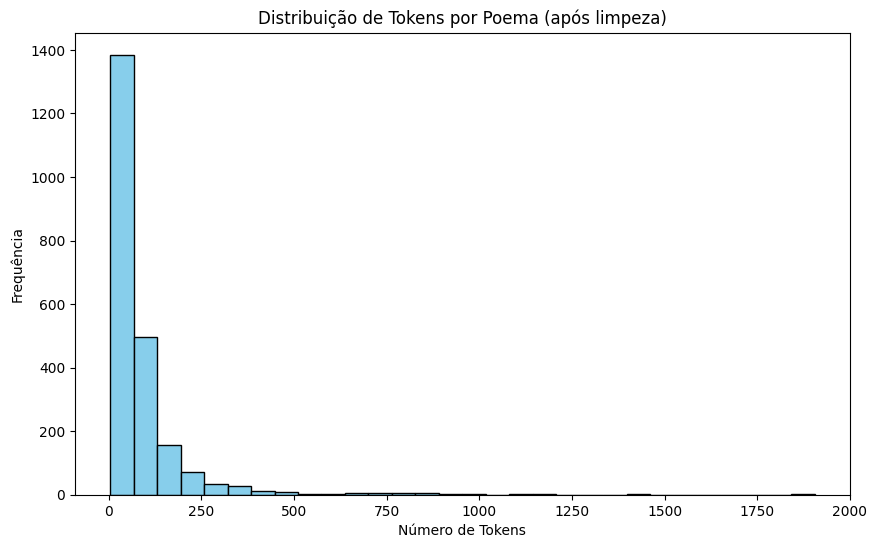

In [40]:
# 5. Visualizar distribuição
plt.figure(figsize=(10, 6))
plt.hist(df_pessoa['num_tokens'], bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Número de Tokens')
plt.ylabel('Frequência')
plt.title('Distribuição de Tokens por Poema (após limpeza)')
plt.savefig('tokens_distribution.png', dpi=150)
plt.show()

# Tarefa 3: Vetorização com TF (CountVectorizer)

In [41]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [42]:
# 1. Preparar textos limpos como strings
textos = df_pessoa['texto_sem_numeros'].values

In [44]:
# 2. CountVectorizer com unigramas
vectorizer_tf = CountVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500
)

In [45]:
# 3. Treinar e transformar
X_tf = vectorizer_tf.fit_transform(textos)
feature_names = vectorizer_tf.get_feature_names_out()

In [46]:
# 4. Calcular frequências
term_freq = np.asarray(X_tf.sum(axis=0)).flatten()
term_freq_sorted = sorted(zip(feature_names, term_freq), 
                        key=lambda x: x[1], reverse=True)

In [47]:
# 5. Top 20 termos mais frequentes
print("=== Top 20 Termos Mais Frequentes (Unigramas) ===")
for i, (termo, freq) in enumerate(term_freq_sorted[:20], 1):
    print(f"{i:2d}. {termo:15s} : {int(freq):4d}")

=== Top 20 Termos Mais Frequentes (Unigramas) ===
 1. the             : 2283
 2. and             : 1809
 3. of              : 1414
 4. to              : 1050
 5. tudo            :  993
 6. vida            :  978
 7. mim             :  910
 8. that            :  908
 9. alma            :  831
10. in              :  783
11. nada            :  759
12. my              :  707
13. is              :  635
14. porque          :  607
15. onde            :  587
16. sei             :  575
17. ter             :  514
18. mundo           :  459
19. deus            :  440
20. with            :  430


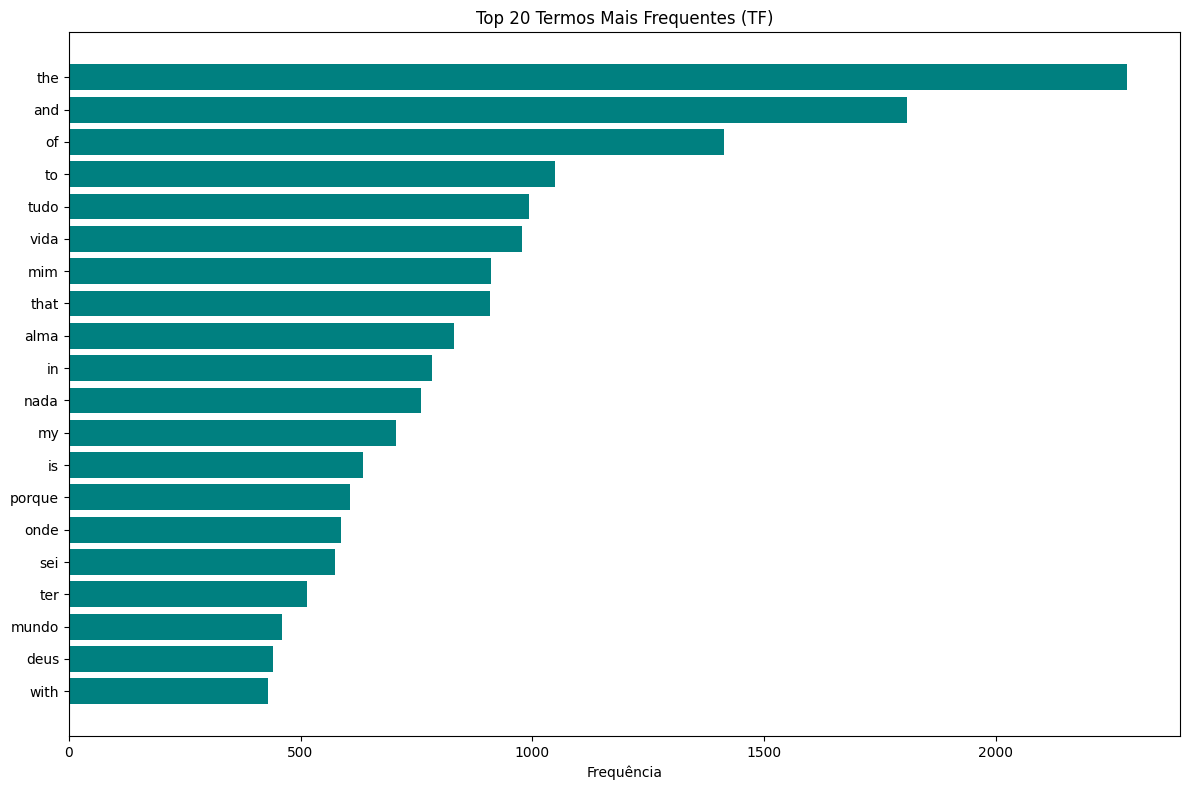

In [48]:
# 6. Visualizar
top_20 = term_freq_sorted[:20]
termos = [t[0] for t in top_20]
freqs = [t[1] for t in top_20]

plt.figure(figsize=(12, 8))
plt.barh(termos, freqs, color='teal')
plt.xlabel('Frequência')
plt.title('Top 20 Termos Mais Frequentes (TF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_terms_tf_unigrams.png', dpi=150)
plt.show()

In [49]:
# 7. Bigramas
print("\n=== Bigramas Mais Frequentes ===")
vectorizer_bigram = CountVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(2, 2),
    max_features=100
)
X_bigram = vectorizer_bigram.fit_transform(textos)
bigram_names = vectorizer_bigram.get_feature_names_out()
bigram_freq = np.asarray(X_bigram.sum(axis=0)).flatten()
bigram_sorted = sorted(zip(bigram_names, bigram_freq), 
                    key=lambda x: x[1], reverse=True)

for i, (bigrama, freq) in enumerate(bigram_sorted[:10], 1):
    print(f"{i:2d}. {bigrama:25s} : {int(freq):3d}")


=== Bigramas Mais Frequentes ===
 1. and the                   : 166
 2. of the                    : 165
 3. in the                    : 152
 4. qualquer coisa            :  92
 5. my soul                   :  84
 6. to be                     :  71
 7. to the                    :  70
 8. ho ho                     :  69
 9. my heart                  :  69
10. from the                  :  65


# Tarefa 4: Vetorização com TF-IDF

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [51]:
# 1. TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500,
    norm='l2'
)

In [52]:
# 2. Treinar e transformar
X_tfidf = vectorizer_tfidf.fit_transform(textos)
tfidf_names = vectorizer_tfidf.get_feature_names_out()

In [53]:
# 3. Calcular scores TF-IDF globais
tfidf_scores = np.asarray(X_tfidf.sum(axis=0)).flatten()
tfidf_sorted = sorted(zip(tfidf_names, tfidf_scores), 
                    key=lambda x: x[1], reverse=True)

print("=== Top 15 Termos por TF-IDF (Global) ===")
for i, (termo, score) in enumerate(tfidf_sorted[:15], 1):
    print(f"{i:2d}. {termo:15s} : {score:.6f}")

=== Top 15 Termos por TF-IDF (Global) ===
 1. the             : 97.142607
 2. vida            : 91.865816
 3. tudo            : 82.168123
 4. nada            : 80.367663
 5. mim             : 78.972349
 6. and             : 73.717993
 7. alma            : 73.362102
 8. sei             : 66.809042
 9. porque          : 64.631854
10. onde            : 61.226274
11. ter             : 58.060977
12. of              : 57.679817
13. coração         : 56.895979
14. to              : 50.027158
15. mundo           : 48.610569


In [56]:
# 4. Comparar TF vs TF-IDF por autor
print("\n=== Comparação TF vs TF-IDF por Autor ===")
for autor in heteronimos:
    textos_autor = df_pessoa[df_pessoa['Author'] == autor]['texto_sem_numeros'].values
    
    if len(textos_autor) > 0:
        # TF
        vect_tf_autor = CountVectorizer(
            lowercase=True, 
            stop_words=list(stop_words), 
            max_features=15
        )
        X_tf_autor = vect_tf_autor.fit_transform(textos_autor)
        tf_nomes = vect_tf_autor.get_feature_names_out()
        tf_freq = np.asarray(X_tf_autor.sum(axis=0)).flatten()
        tf_sorted = sorted(zip(tf_nomes, tf_freq), key=lambda x: x[1], reverse=True)
        
        # TF-IDF
        vect_tfidf_autor = TfidfVectorizer(
            lowercase=True, 
            stop_words=list(stop_words), 
            max_features=15,
            norm='l2'
        )
        X_tfidf_autor = vect_tfidf_autor.fit_transform(textos_autor)
        tfidf_nomes = vect_tfidf_autor.get_feature_names_out()
        tfidf_scores_autor = np.asarray(X_tfidf_autor.sum(axis=0)).flatten()
        tfidf_sorted_autor = sorted(zip(tfidf_nomes, tfidf_scores_autor), 
                                key=lambda x: x[1], reverse=True)
        
        print(f"\n{'='*50}")
        print(f"AUTOR: {autor}")
        print(f"{'='*50}")
        print(f"{'Top 10 por TF':<35} | {'Top 10 por TF-IDF':<35}")
        print("-" * 72)
        for j in range(10):
            tf_item = f"{j+1}. {tf_sorted[j][0]}" if j < len(tf_sorted) else ""
            tfidf_item = f"{j+1}. {tfidf_sorted_autor[j][0]}" if j < len(tfidf_sorted_autor) else ""
            print(f"{tf_item:<35} | {tfidf_item:<35}")


=== Comparação TF vs TF-IDF por Autor ===

AUTOR: Fernando Pessoa
Top 10 por TF                       | Top 10 por TF-IDF                  
------------------------------------------------------------------------
1. the                              | 1. vida                            
2. and                              | 2. tudo                            
3. of                               | 3. mim                             
4. to                               | 4. alma                            
5. tudo                             | 5. nada                            
6. vida                             | 6. porque                          
7. mim                              | 7. onde                            
8. that                             | 8. the                             
9. alma                             | 9. and                             
10. in                              | 10. of                             


In [58]:
# 5. Testar normalizações L1 vs L2
print("\n=== Comparação L1 vs L2 ===")
vect_l1 = TfidfVectorizer(norm='l1', max_features=100, lowercase=True, stop_words=list(stop_words))
vect_l2 = TfidfVectorizer(norm='l2', max_features=100, lowercase=True, stop_words=list(stop_words))

X_l1 = vect_l1.fit_transform(textos)
X_l2 = vect_l2.fit_transform(textos)

print(f"Norma L1 (Manhattan) - Soma de um vetor: {X_l1[0].sum():.6f}")
print(f"Norma L2 (Euclidiana) - Norma de um vetor: {np.sqrt((X_l2[0].data**2).sum()):.6f}")


=== Comparação L1 vs L2 ===
Norma L1 (Manhattan) - Soma de um vetor: 1.000000
Norma L2 (Euclidiana) - Norma de um vetor: 1.000000


# Tarefa 5: Visualização com Word Clouds

In [60]:
from wordcloud import WordCloud

Gerando word clouds por autor...
  ✓ Salvo: wordcloud_fernando_pessoa.png


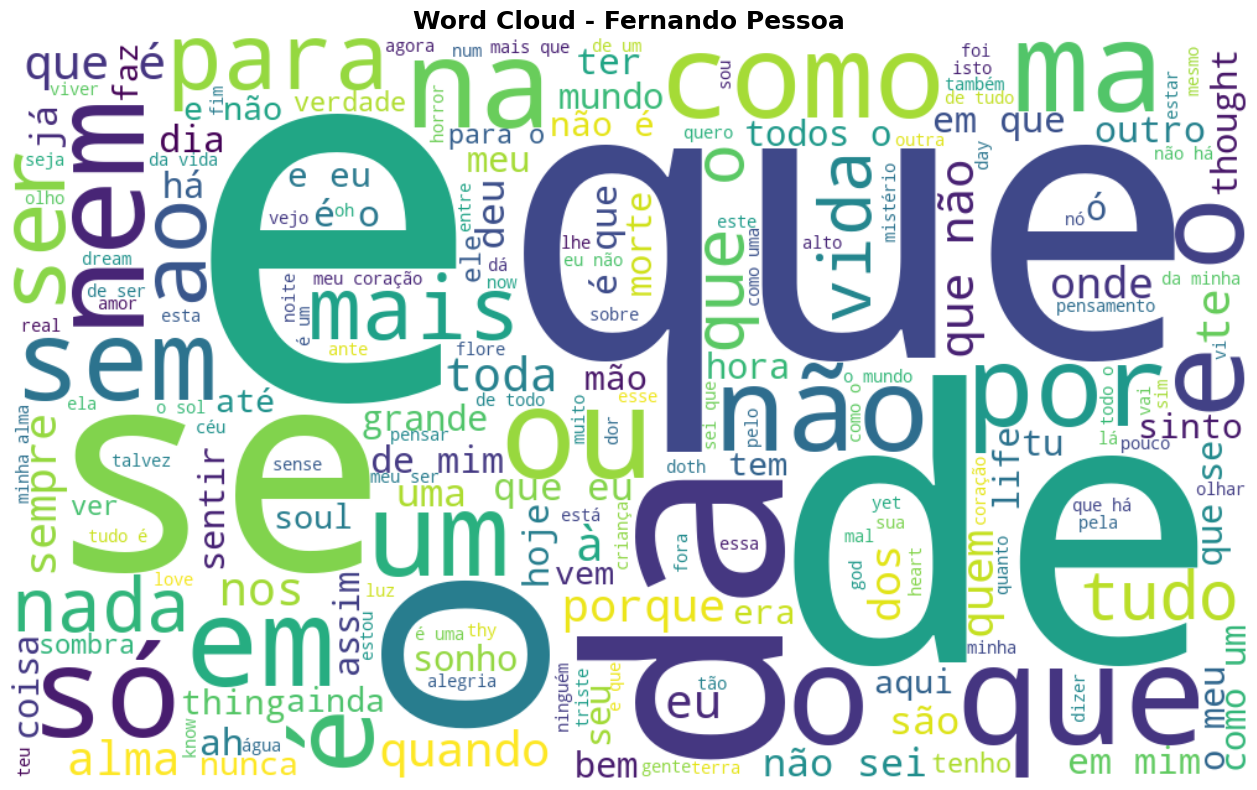

In [62]:
# 1. Word Cloud por Autor
print("Gerando word clouds por autor...")
for autor in heteronimos:
    textos_autor = ' '.join(df_pessoa[df_pessoa['Author'] == autor]['texto_sem_numeros'].values)
    
    if len(textos_autor) > 50:  # Apenas se houver texto suficiente
        wc = WordCloud(
            width=1000, 
            height=600, 
            background_color='white',
            colormap='viridis',
            prefer_horizontal=0.7,
            random_state=42
        ).generate(textos_autor)
        
        plt.figure(figsize=(15, 8))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f'Word Cloud - {autor}', fontsize=18, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        filename = f'wordcloud_{autor.replace(" ", "_").lower()}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"  ✓ Salvo: {filename}")
        plt.show()

In [63]:
# 2. Word Cloud TF vs TF-IDF para um autor
autor_escolhido = 'Álvaro de Campos'
textos_escolhido = ' '.join(
    df_pessoa[df_pessoa['Author'] == autor_escolhido]['texto_sem_numeros'].values
)

if len(textos_escolhido) > 50:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # TF
    wc_tf = WordCloud(width=800, height=400, background_color='white', 
                      colormap='Blues', random_state=42).generate(textos_escolhido)
    axes[0].imshow(wc_tf, interpolation='bilinear')
    axes[0].set_title(f'TF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # TF-IDF
    wc_tfidf = WordCloud(width=800, height=400, background_color='white', 
                         colormap='Reds', random_state=42).generate(textos_escolhido)
    axes[1].imshow(wc_tfidf, interpolation='bilinear')
    axes[1].set_title(f'TF-IDF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('wordcloud_tf_vs_tfidf_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Salvo: wordcloud_tf_vs_tfidf_comparison.png")
    plt.show()

# Tarefa 6: Análise de Similaridade entre Poemas (Desafio)

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

In [66]:
# 1. Calcular matriz de similaridade
similarity_matrix = cosine_similarity(X_tfidf)

In [68]:
# 2. Selecionar um poema de referência
idx_campos = (df_pessoa['Author'] == 'Álvaro de Campos').values
indices_campos = np.where(idx_campos)[0]

if len(indices_campos) > 0:
    idx_referencia = indices_campos[0]
    similares = similarity_matrix[idx_referencia].argsort()[::-1][1:6]
    
    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: {df_pessoa.iloc[idx_referencia]['Author']}")
    print(f"{'='*70}")
    print(f"{df_pessoa.iloc[idx_referencia]['text'][:200]}...\n")
    
    print("POEMAS MAIS SIMILARES:")
    for i, idx_similar in enumerate(similares, 1):
        sim_score = similarity_matrix[idx_referencia, idx_similar]
        autor = df_pessoa.iloc[idx_similar]['Author']
        texto = df_pessoa.iloc[idx_similar]['text'][:150]
        print(f"\n{i}. [{sim_score:.4f}] {autor}")
        print(f"   {texto}...")

In [70]:
# 3. Comparar com outro autor (Ricardo Reis)
idx_reis = (df_pessoa['Author'] == 'Ricardo Reis').values
indices_reis = np.where(idx_reis)[0]

if len(indices_reis) > 0:
    idx_ref_reis = indices_reis[0]
    similares_reis = similarity_matrix[idx_ref_reis].argsort()[::-1][1:6]
    
    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: Ricardo Reis")
    print(f"{'='*70}")
    print(f"{df_pessoa.iloc[idx_ref_reis]['text'][:200]}...\n")
    
    print("POEMAS MAIS SIMILARES:")
    for i, idx_sim in enumerate(similares_reis, 1):
        sim_score = similarity_matrix[idx_ref_reis, idx_sim]
        autor = df_pessoa.iloc[idx_sim]['Author']
        print(f"{i}. [{sim_score:.4f}] {autor}")

# Tarefa 7: Relatório Final

Estrutura do Relatório: <br>
Introdução (5-10 linhas) <br><br>

Contexto do dataset<br>
Objetivos principais<br>
Metodologia (10-15 linhas)<br><br>

Técnicas: TF, TF-IDF, normalização<br>
Pré-processamento aplicado<br>
Resultados (20-30 linhas)<br><br>

Estatísticas principais<br>
Termos mais relevantes por autor<br>
Padrões descobertos<br>
Discussão (15-20 linhas)<br><br>

Interpretação dos resultados<br>
Diferenças entre autores<br>
Limitações da abordagem<br>
Conclusão (5-10 linhas)<br><br>

Aprendizados principais<br>
Código para Gerar Sumário:

In [ ]:
# Sumário dos resultados
print("\n" + "="*70)
print("SUMÁRIO DA ANÁLISE")
print("="*70)

print(f"\n1. DATASET:")
print(f"   • Total de poemas: {len(df_pessoa)}")
print(f"   • Autores analisados: {heteronimos}")
print(f"   • Distribuição: {dict(df_pessoa['author'].value_counts())}")

print(f"\n2. VOCABULÁRIO:")
print(f"   • Termos únicos totais: {len(feature_names)}")
print(f"   • Termo mais frequente: '{term_freq_sorted[0][0]}' ({int(term_freq_sorted[0][1])} ocorrências)")
print(f"   • Comprimento médio de poema: {df_pessoa['num_tokens'].mean():.0f} tokens")

print(f"\n3. TERMOS DISCRIMINATIVOS (TF-IDF):")
print(f"   • Top 3 globais: {', '.join([t[0] for t in tfidf_sorted[:3]])}")

print(f"\n4. BIGRAMAS:")
print(f"   • Bigrama mais frequente: '{bigram_sorted[0][0]}' ({int(bigram_sorted[0][1])} ocorrências)")

print("\n" + "="*70 + "\n")